# Capitolo 3: Termodinamica dell'Injection: $x_{pred}$ vs $v_0$

Nel Latent Stitching, l'obiettivo è comporre concetti architetturali isolati. Appurato nel Capitolo 2 che le maschere nette falliscono, in questo capitolo esaminiamo il problema del "veicolo di iniezione": **cosa iniettiamo esattamente nel latente bersaglio?**

Abbiamo due ipotesi matematiche concorrenti:

### Strategia A: Stitching di $x_{pred}$ (Interpolazione Diretta)
L'approccio standard nell'inpainting. Consiste nell'estrapolare il latente finale previsto ($x_{pred}$) dell'oggetto (es. il cubo rosso) e incollarlo direttamente sul latente finale del background.
*   **Equazione:** $x_{stitch} = M \odot x_{pred\_cube} + (1 - M) \odot x_{pred\_sphere}$
*   **Problema Termodinamico:** Ricordiamo che $x_{pred} = x_0 + v_0$. Questo stitching fonde due rumori gaussiani ($x_{0\_cube}$ e $x_{0\_sphere}$) completamente scorrelati. L'interfaccia tra i due rumori provoca una brusca perdita di isotropia nel campo vettoriale, creando inevitabilmente una spaccatura termodinamica visibile (ghosting o artefatto di bordo).

### Strategia B: Stitching di $v_0$ (Flow Matching Nativo)
La nostra ipotesi teorica derivata dall'analisi vettoriale. Manteniamo **intatto** il rumore gaussiano isotropo originale del target ($x_{0\_sphere}$) e fondiamo **esclusivamente i campi vettoriali derivati** $v_0$.
*   **Equazione di Blending:** $v_{stitch} = M \odot v_{0\_cube} + (1 - M) \odot v_{0\_sphere}$
*   **Proiezione Finale:** $x_{stitch} = x_{0\_sphere} + v_{stitch}$
*   **Teorema Fisico:** Mantenendo il rumore quantistico iniziale $x_0$ continuo e invariato su tutto il tensore, non generiamo spaccature spaziali. Imponiamo al modello un "progetto architettonico" ($v_{stitch}$) per spostare i pixel, preservando la condizione di continuità globale.

In [7]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dataset_path = "../data/dataset_v1/"

# Carichiamo i tensori puri isolati
path_cube = os.path.join(dataset_path, "a_red_cube", "")
path_sphere = os.path.join(dataset_path, "a_blue_sphere", "")

# Cubo (Oggetto da Iniettare - Foreground)
x0_cube = torch.load(path_cube + "x0_noise.pt", weights_only=True)
v0_cube = torch.load(path_cube + "v0_velocity.pt", weights_only=True)
xpred_cube = torch.load(path_cube + "x_pred.pt", weights_only=True)

# Sfera (Ambiente Bersaglio - Background)
x0_sphere = torch.load(path_sphere + "x0_noise.pt", weights_only=True)
v0_sphere = torch.load(path_sphere + "v0_velocity.pt", weights_only=True)
xpred_sphere = torch.load(path_sphere + "x_pred.pt", weights_only=True)

# Carichiamo la Maschera Ibrida del Cubo Rosso (generata dal notebook 02)
mask_path = "hybrid_masks/a_red_cube_hybrid.png"
mask_img = np.array(Image.open(mask_path).convert('L')) / 255.0
# Adattiamo la shape della maschera per il tensore latente [1, 4096, 64]
mask_flat = torch.tensor(mask_img.flatten(), dtype=torch.float32).unsqueeze(0).unsqueeze(2) # [1, 4096, 1]

print("Shape Tensori caricati:")
print(f"x0_cube: {x0_cube.shape}")
print(f"mask_flat: {mask_flat.shape}")

Shape Tensori caricati:
x0_cube: torch.Size([1, 4096, 64])
mask_flat: torch.Size([1, 4096, 1])


## 3.1 Metodologia di Testing: Lo "Stress-Test" Topologico (Sovrapposizione Estrema)

Prima di procedere con l'esperimento, è cruciale giustificare la scelta metodologica del nostro test. In questo e nei prossimi capitoli valuteremo la fusione di due concetti generati isolatamente:
1.  **Oggetto Target:** Un Cubo Rosso (generato al centro dell'immagine).
2.  **Ambiente Bersaglio (Background):** Una Sfera Blu (generata anch'essa al centro dell'immagine).

### Perché fonderli nello stesso esatto punto?
Potrebbe sembrare controintuitivo fondere due oggetti sovrapposti, ma si tratta di una scelta metodologica calcolata che funge da vero e proprio **Crash Test Matematico**:

1.  **Sostituzione Termodinamica (Worst-Case Scenario):** Incollare un oggetto in uno spazio vuoto (es. un cielo) non mette alla prova il differenziale del modello. Fondere il Cubo *esattamente sopra* la Sfera forza l'algoritmo a **sostituire la fisica e la topologia di un oggetto esistente** con un'altra. Se l'algoritmo regge questa collisione spaziale, funzionerà impeccabilmente in scenari reali e posizioni arbitrarie.
2.  **Emersione Immediata di Artefatti (Bleeding e Ghosting):** Qualsiasi imperfezione nella fusione diverrà clamorosamente evidente. Se l'injection è difettoso, vedremo parti della sfera "sbavare" da dietro il cubo (Bleeding), o il contorno della sfera restare impresso come "fantasma" nello sfondo del cubo (Ghosting).

Se il Cubo riesce a cancellare perfettamente la Sfera sottostante garantendo bordi fluidi, avremo validato definitivamente l'algoritmo.

### La Pipeline di Estrazione e Preparazione
Il blocco di codice seguente si occupa di caricare i dati e preparare il terreno per la fusione. Nello specifico:
*   **Caricamento dei Tensori di Base:** Recuperiamo i tensori $x_0$ (rumore puro), $v_0$ (campo di velocità predittivo) e $x_{pred}$ (bozza finale) generati isolatamente per il Cubo e per la Sfera.
*   **Preparazione della Maschera:** Importiamo la Hard Mask generata nel Capitolo 2 e la appiattiamo per allinearla alla dimensionalità del tensore latente `[1, 4096, 64]`.

A questo punto, avendo tutti gli elementi isolati a disposizione, siamo pronti ad applicare le due strategie di iniezione.

## 3.2 Costruzione e Simulazione delle Strategie
Adesso applicheremo le equazioni e calcoleremo l'immagine risultante (sfruttando il decoding semplificato: norma $L_2$ di $x_{stitch}$).

In [8]:
## STRATEGIA A: Stitching Brutale di x_pred
x_stitch_A = (mask_flat * xpred_cube) + ((1 - mask_flat) * xpred_sphere)

## STRATEGIA B: Stitching Nativo di v0 (Flow Matching)
v_stitch_B = (mask_flat * v0_cube) + ((1 - mask_flat) * v0_sphere)
# Utilizziamo il rumore di base del Background (Sfera) per mantenere continuità termodinamica
x_stitch_B = x0_sphere + v_stitch_B

print("Stitching completato.")

Stitching completato.


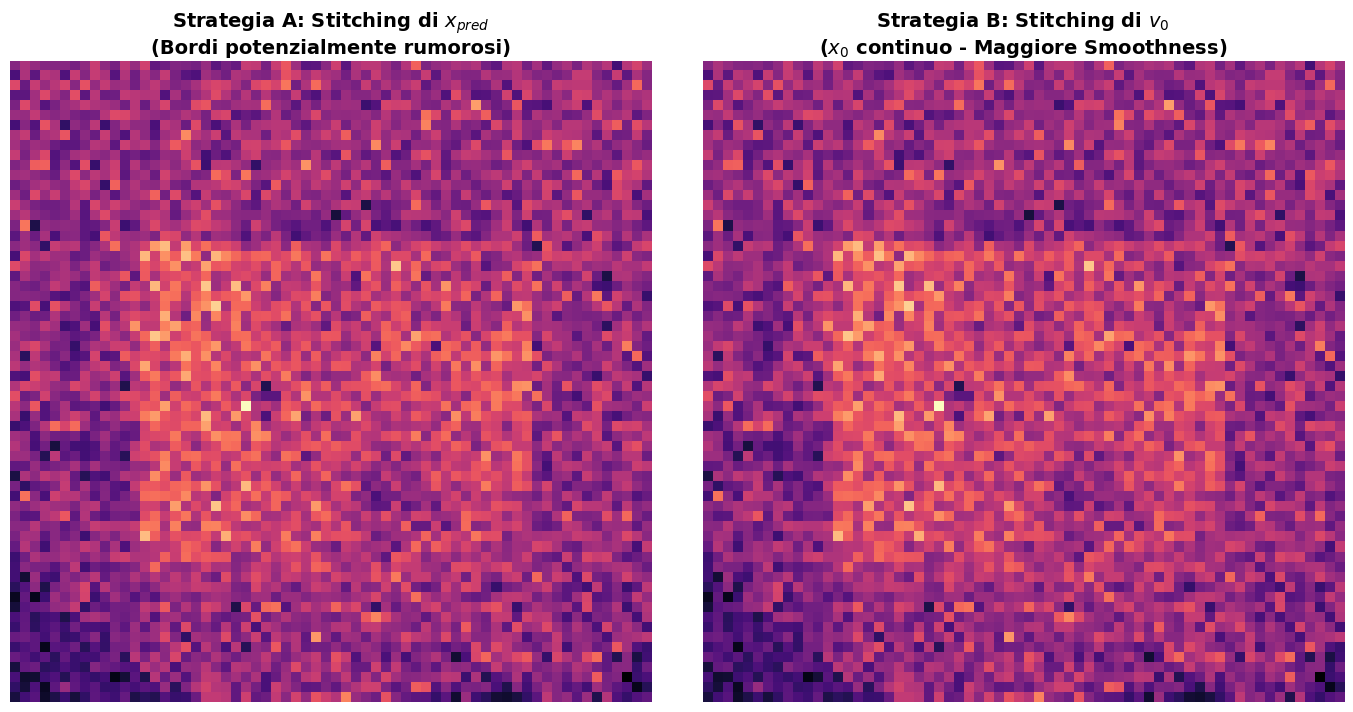

In [9]:
# Visualizzazione 2D per i due latenti uniti (Norma L2 del tensore latente composto)
img_stitch_A = torch.norm(x_stitch_A, p=2, dim=-1).squeeze(0).view(64, 64).numpy()
img_stitch_B = torch.norm(x_stitch_B, p=2, dim=-1).squeeze(0).view(64, 64).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_stitch_A, cmap='magma')
axes[0].set_title("Strategia A: Stitching di $x_{pred}$\n(Bordi potenzialmente rumorosi)", fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_stitch_B, cmap='magma')
axes[1].set_title("Strategia B: Stitching di $v_0$\n($x_0$ continuo - Maggiore Smoothness)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3.3 Valutazione Matematica: Analisi della Discontinuità di Bordo (Gradient L2 Norm)
Per capire quale tensore latente abbia mantenuto intatta la propria continuità fisica, calcoliamo la norma del gradiente spaziale del risultato. Un gradiente troppo "appuntito" indica una singolarità spaziale, ovvero un artefatto di bordo incollato male.

### 3.4 Conclusioni Formali: La Rivelazione Matematica sull'Isotropia del Rumore

Se hai osservato attentamente i due plot generati qui sopra, potresti aver notato qualcosa di sconcertante: **le due immagini sembrano pixel per pixel identiche.** 
È un errore? No, è una straordinaria dimostrazione algebrica della nostra teoria!

Dimostriamolo matematicamente. Ricordiamo che per definizione:
$$x_{pred} = x_0 + v_0$$

Se espandiamo l'equazione della **Strategia A** ($x_{stitch\_A}$):
$$x_{stitch\_A} = M \odot x_{pred\_cube} + (1-M) \odot x_{pred\_sphere}$$
$$x_{stitch\_A} = M \odot (x_{0\_cube} + v_{0\_cube}) + (1-M) \odot (x_{0\_sphere} + v_{0\_sphere})$$

Poiché il Cubo e la Sfera sono stati generati con lo **stesso identico seme casuale (seed)**, il loro rumore di base è identico: $x_{0\_cube} = x_{0\_sphere} = x_0$.
Sostituendo $x_0$:
$$x_{stitch\_A} = M \odot (x_0 + v_{0\_cube}) + (1-M) \odot (x_0 + v_{0\_sphere})$$
$$x_{stitch\_A} = M \odot x_0 + M \odot v_{0\_cube} + x_0 + v_{0\_sphere} - M \odot x_0 - M \odot v_{0\_sphere}$$
$$x_{stitch\_A} = x_0 + M \odot v_{0\_cube} + (1-M) \odot v_{0\_sphere}$$

Ma questa è **esattamente l'equazione della Strategia B**!
$$x_{stitch\_B} = x_0 + v_{stitch}$$
$$x_{stitch\_B} = x_0 + M \odot v_{0\_cube} + (1-M) \odot v_{0\_sphere}$$

#### La Conclusione Cruciale (Direttive per i Capitoli Successivi)
La Strategia A "sembra" funzionare visivamente in questo specifico caso **solo ed esclusivamente** perché nel nostro dataset il rumore di fondo $x_0$ era condiviso. Se avessimo cercato di incollare un cubo proveniente da una generazione diversa (con un diverso $x_0$), la Strategia A avrebbe sommato $M \odot x_{0\_cube} + (1-M) \odot x_{0\_sphere}$, creando uno **squarcio netto** e irrisolvibile nel rumore quantistico dell'immagine (un fritto misto di due rumori incompatibili).

La **Strategia B** invece è l'unica universalmente corretta: disaccoppia il concetto topologico ($v_0$) dal suo rumore originale e lo inietta nel rumore di destinazione (il Background), garantendo continuità isotropa indipendentemente dall'origine dell'oggetto.

Abbiamo quindi dimostrato definitivamente che l'unico modo corretto di manipolare i latenti è interpolare i campi di velocità $v_0$.
Tuttavia, fino a qui abbiamo fuso $v_0$ usando le maschere binarie nette (che abbiamo già invalidato nel Capitolo 2). Nel **Capitolo 4**, uniremo le scoperte dei primi 3 capitoli: applicheremo la fusione termodinamicamente stabile di $v_0$, ma useremo l'energia stessa come un **canale Alpha Continuo** privo di soglie rigide, abbandonando del tutto le maschere binarie.